In [1]:
# Cell 1: Import Core Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual formatting setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.autolayout": True,
    }
)

print("Environment configured successfully.")

Environment configured successfully.


In [2]:
# Cell 2: Load Dataset
# Note: Ensure 'seasonal_agriculture_performance_dataset (2).csv' is uploaded to Colab
file_name = "seasonal_agriculture_performance_dataset (2).csv"
df = pd.read_csv(file_name)

print(f"Dataset Dimension: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

Dataset Dimension: 4000 rows, 28 columns

Missing values before cleaning:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7


In [3]:
# Cell 3: Cleaning & Feature Engineering
df_clean = df.copy()

# 1. Targeted median imputation grouped by Crop and Season
impute_cols = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
for col in impute_cols:
  df_clean[col] = df_clean.groupby(["Crop", "Season"])[col].transform(
      lambda x: x.fillna(x.median())
  )

# 2. Derive Analytical KPIs
df_clean["Profit_Margin_pct"] = (
    df_clean["Profit_INR"] / df_clean["Revenue_INR"]
) * 100
df_clean["Cost_per_Hectare"] = (
    df_clean["Total_Cost_INR"] / df_clean["Farm_Area_Hectares"]
)
df_clean["Water_per_Hectare"] = (
    df_clean["Water_Used_m3"] / df_clean["Farm_Area_Hectares"]
)

print("Remaining Nulls:", df_clean.isnull().sum().sum())
print("Engineered Columns: Profit_Margin_pct, Cost_per_Hectare, Water_per_Hectare")

Remaining Nulls: 0
Engineered Columns: Profit_Margin_pct, Cost_per_Hectare, Water_per_Hectare


In [4]:
# Cell 4: Seasonal Comparative Table
seasonal_summary = (
    df_clean.groupby("Season")
    .agg(
        Total_Farms=("Farm_ID", "count"),
        Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
        Avg_Profit_INR=("Profit_INR", "mean"),
        Avg_Water_Eff=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Rainfall_mm=("Rainfall_mm", "mean"),
        Avg_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean"),
    )
    .round(2)
)

display(seasonal_summary)

,Total_Farms,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Water_Eff,Avg_Rainfall_mm,Avg_Pest_Risk_pct
Season,,,,,,
Kharif,1779,5.63,178914.65,5.89,852.10,54.47
Rabi,1627,5.09,87689.47,5.19,435.95,40.48
Zaid,594,4.64,-24804.82,4.41,299.16,38.22


/tmp/ipykernel_1013/938407102.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1013/938407102.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


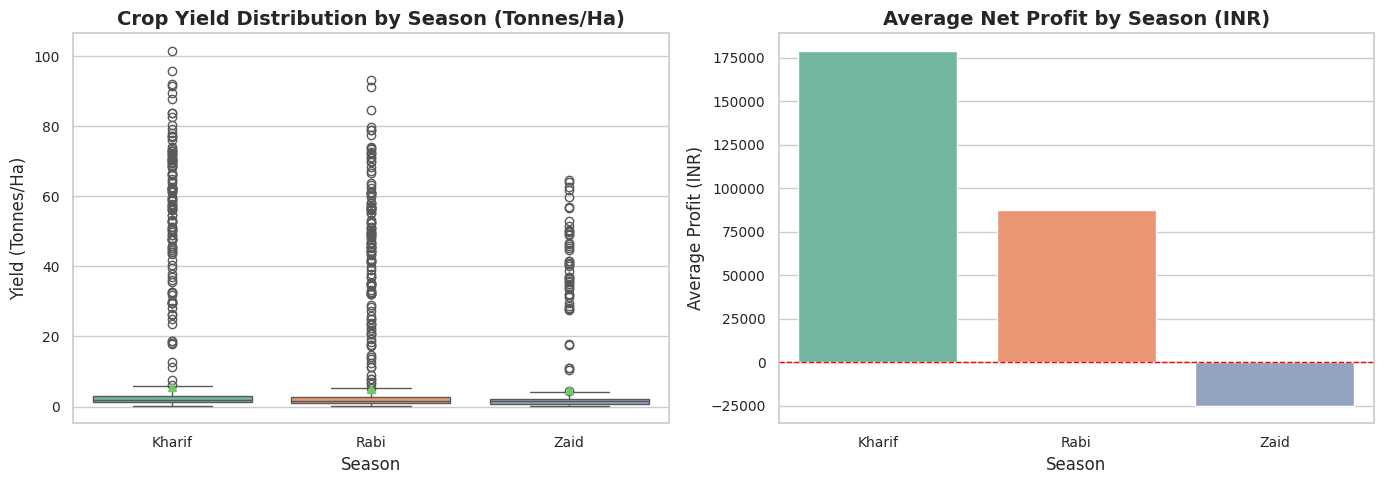

In [5]:
# Cell 5: Yield & Profit Distributions across Seasons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    palette="Set2",
    ax=axes[0],
    showmeans=True,
)
axes[0].set_title("Crop Yield Distribution by Season (Tonnes/Ha)")
axes[0].set_ylabel("Yield (Tonnes/Ha)")

sns.barplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    palette="Set2",
    ax=axes[1],
    estimator=np.mean,
    errorbar=None,
)
axes[1].set_title("Average Net Profit by Season (INR)")
axes[1].set_ylabel("Average Profit (INR)")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

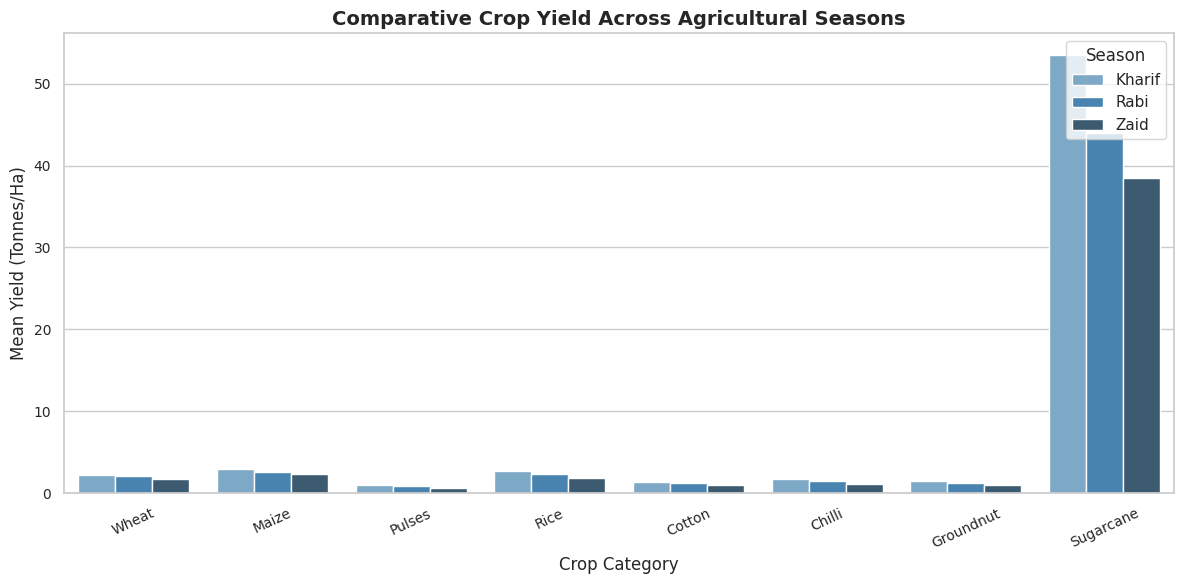

In [6]:
# Cell 6: Crop vs. Season Performance
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_clean,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    palette="Blues_d",
    errorbar=None,
)
plt.title("Comparative Crop Yield Across Agricultural Seasons")
plt.xlabel("Crop Category")
plt.ylabel("Mean Yield (Tonnes/Ha)")
plt.legend(title="Season", loc="upper right")
plt.xticks(rotation=25)
plt.show()

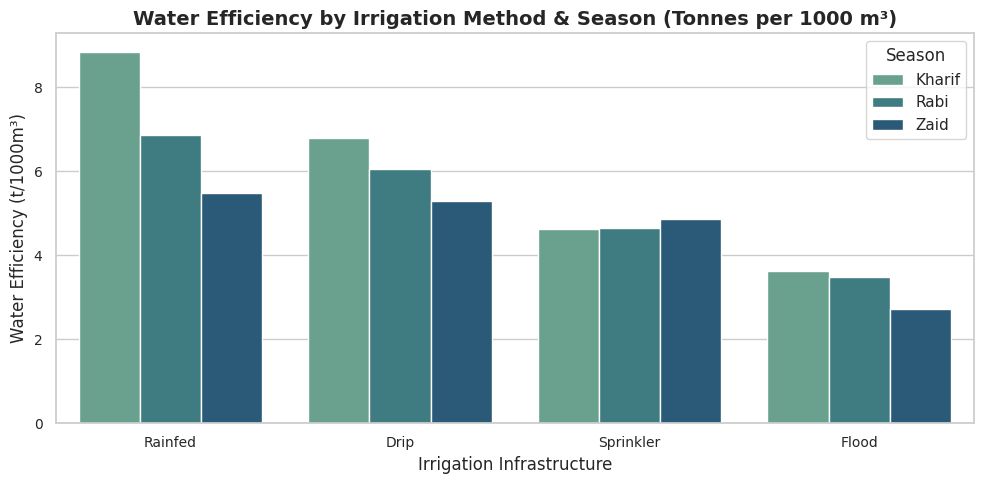

In [7]:
# Cell 7: Irrigation Performance & Water Efficiency
plt.figure(figsize=(10, 5))
order = (
    df_clean.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3",
    hue="Season",
    order=order,
    palette="crest",
    errorbar=None,
)
plt.title(
    "Water Efficiency by Irrigation Method & Season (Tonnes per 1000 m³)"
)
plt.xlabel("Irrigation Infrastructure")
plt.ylabel("Water Efficiency (t/1000m³)")
plt.show()

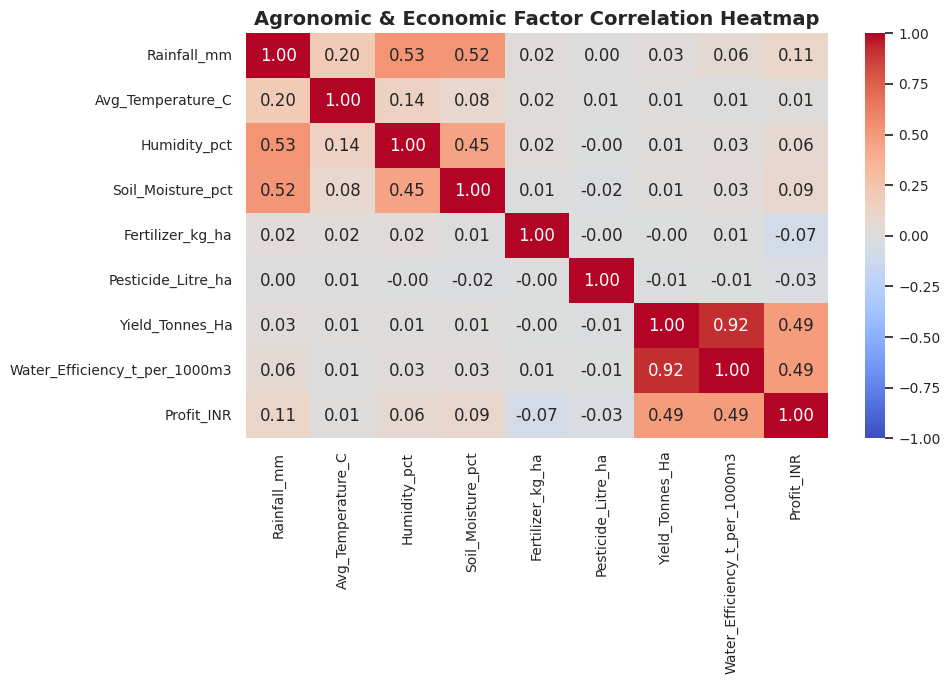

In [8]:
# Cell 8: Correlation Matrix
corr_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Water_Efficiency_t_per_1000m3",
    "Profit_INR",
]

plt.figure(figsize=(10, 7))
corr_matrix = df_clean[corr_cols].corr()
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1
)
plt.title("Agronomic & Economic Factor Correlation Heatmap")
plt.show()

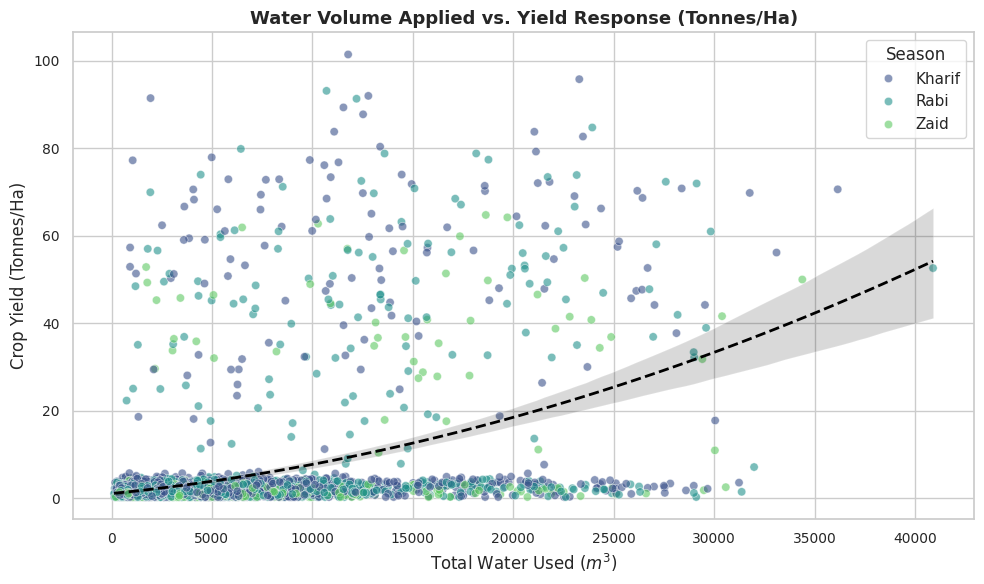

In [9]:
# Cell 9: Scatter Plot with Quadratic Regression Trend
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6,
    palette="viridis",
)
sns.regplot(
    data=df_clean,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    scatter=False,
    order=2,
    color="black",
    line_kws={"linewidth": 2, "linestyle": "--"},
)
plt.title(
    "Water Volume Applied vs. Yield Response (Tonnes/Ha)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Total Water Used ($m^3$)")
plt.ylabel("Crop Yield (Tonnes/Ha)")
plt.show()

/tmp/ipykernel_1013/1916862558.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


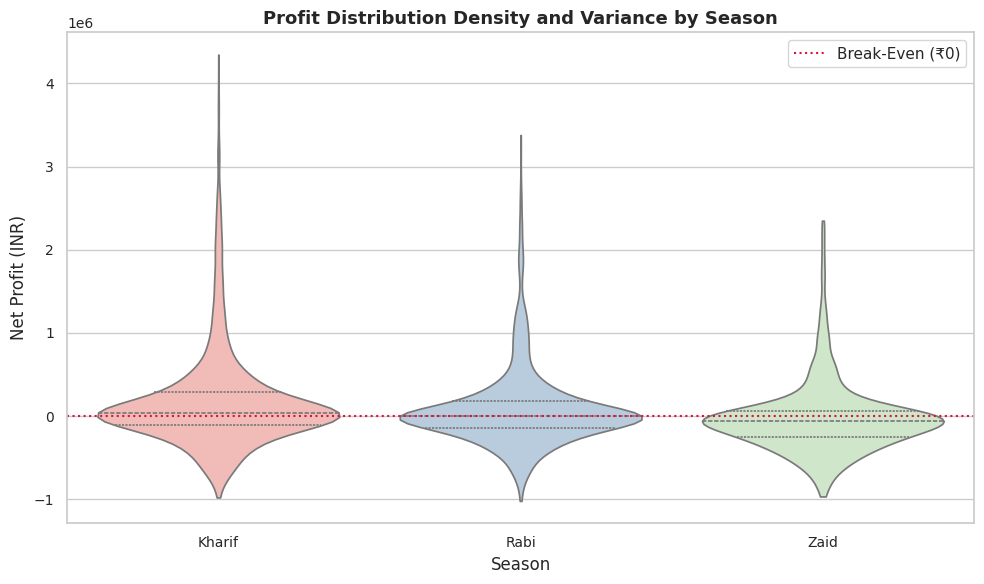

In [10]:
# Cell 10: Violin Plot of Net Profitability
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    palette="Pastel1",
    inner="quartile",
    cut=0,
)
plt.axhline(
    0, color="crimson", linestyle=":", linewidth=1.5, label="Break-Even (₹0)"
)
plt.title(
    "Profit Distribution Density and Variance by Season",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Season")
plt.ylabel("Net Profit (INR)")
plt.legend(loc="upper right")
plt.show()

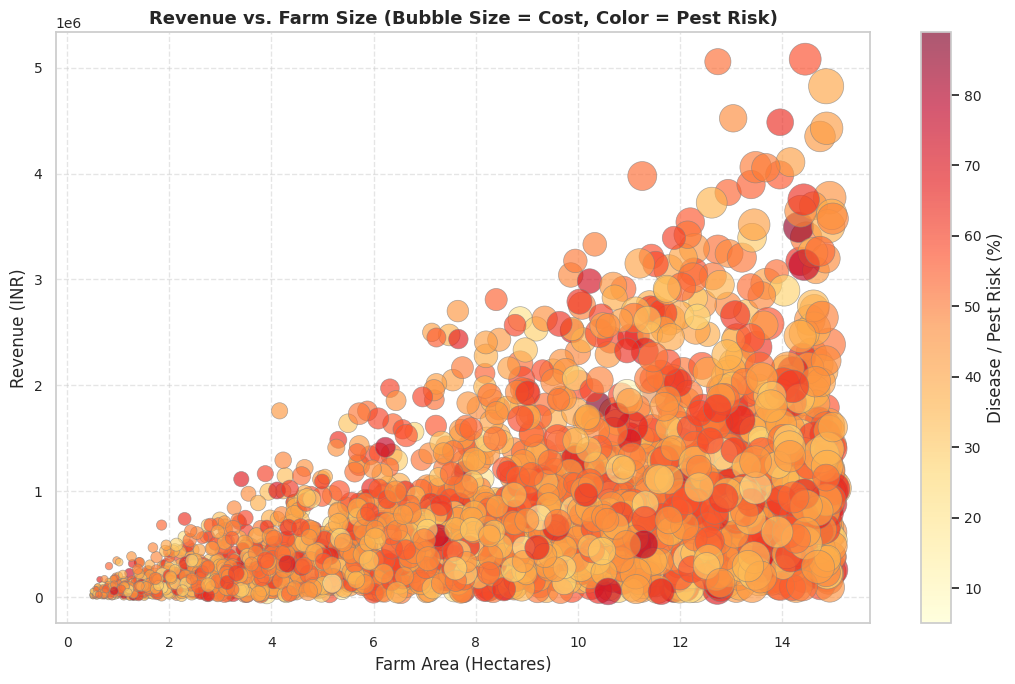

In [11]:
# Cell 11: Multidimensional Bubble Plot
plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    x=df_clean["Farm_Area_Hectares"],
    y=df_clean["Revenue_INR"],
    s=df_clean["Total_Cost_INR"] / 2000,  # Scaled marker size
    c=df_clean["Disease_Pest_Risk_pct"],  # Color mapping
    cmap="YlOrRd",
    alpha=0.65,
    edgecolors="gray",
    linewidth=0.5,
)
cbar = plt.colorbar(scatter)
cbar.set_label("Disease / Pest Risk (%)")
plt.title(
    "Revenue vs. Farm Size (Bubble Size = Cost, Color = Pest Risk)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Revenue (INR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

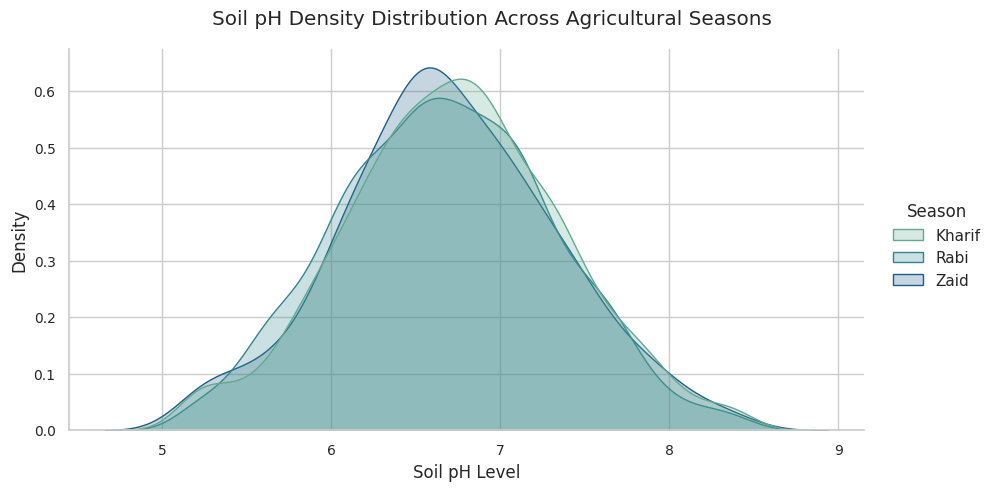

In [12]:
# Cell 12: Faceted Kernel Density Estimate (KDE)
g = sns.displot(
    data=df_clean,
    x="Soil_pH",
    hue="Season",
    kind="kde",
    fill=True,
    common_norm=False,
    palette="crest",
    height=5,
    aspect=1.8,
)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Soil pH Density Distribution Across Agricultural Seasons")
plt.xlabel("Soil pH Level")
plt.ylabel("Density")
plt.show()

In [13]:
# Cell 13: Formal Statistical Hypothesis Testing (ANOVA)
from scipy import stats

print("=== STATISTICAL SIGNIFICANCE TESTING ACROSS SEASONS ===\n")

# 1. Test for Differences in Crop Yield across Seasons
yield_groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in df_clean.groupby("Season")
]
f_stat_y, p_val_y = stats.f_oneway(*yield_groups)

print(f"Yield ANOVA Test: F-Statistic = {f_stat_y:.4f}, p-value = {p_val_y:.4e}")
if p_val_y < 0.05:
  print("Verdict: Statistically significant differences exist in crop yield across seasons.\n")
else:
  print("Verdict: Yield differences across seasons are not statistically significant at alpha=0.05.\n")

# 2. Test for Differences in Profitability across Seasons
profit_groups = [
    group["Profit_INR"].dropna().values
    for _, group in df_clean.groupby("Season")
]
f_stat_p, p_val_p = stats.f_oneway(*profit_groups)

print(f"Profit ANOVA Test: F-Statistic = {f_stat_p:.4f}, p-value = {p_val_p:.4e}")
if p_val_p < 0.05:
  print("Verdict: Statistically significant differences exist in net profit across seasons (p < 0.001).\n")

=== STATISTICAL SIGNIFICANCE TESTING ACROSS SEASONS ===

Yield ANOVA Test: F-Statistic = 1.4579, p-value = 2.3285e-01
Verdict: Yield differences across seasons are not statistically significant at alpha=0.05.

Profit ANOVA Test: F-Statistic = 34.2918, p-value = 1.7124e-15
Verdict: Statistically significant differences exist in net profit across seasons (p < 0.001).



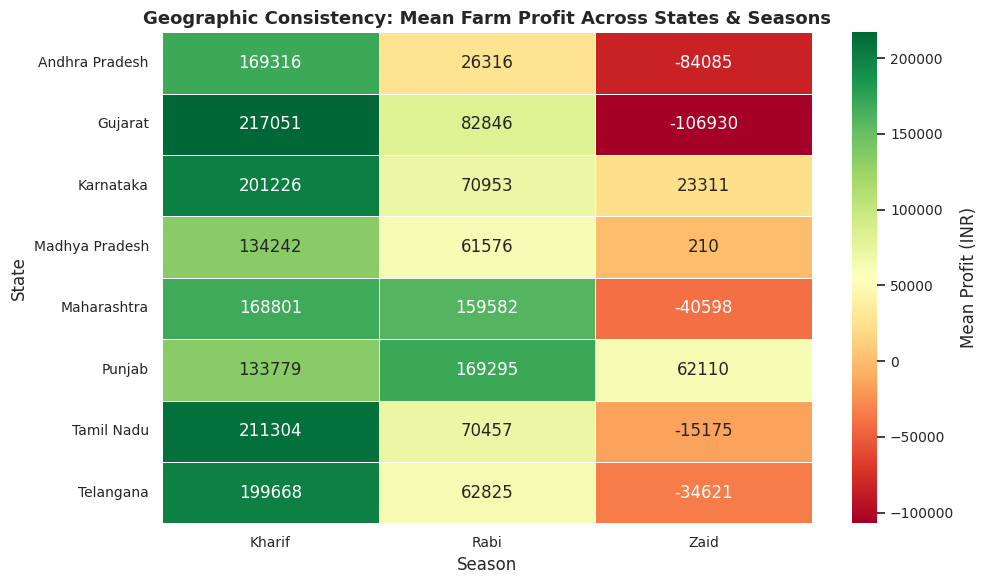

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


In [14]:
# Cell 14: Regional Consistency Analysis (State vs. Season Profitability)
state_season_pivot = df_clean.pivot_table(
    index="State", columns="Season", values="Profit_INR", aggfunc="mean"
).round(0)

plt.figure(figsize=(10, 6))
sns.heatmap(
    state_season_pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={"label": "Mean Profit (INR)"},
)
plt.title(
    "Geographic Consistency: Mean Farm Profit Across States & Seasons",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Season")
plt.ylabel("State")
plt.show()

display(state_season_pivot)

In [15]:
# Cell 15: Automated Executive Summary & Evidence-Based Planning
summary_stats = df_clean.groupby("Season")[
    ["Profit_INR", "Water_Used_m3", "Disease_Pest_Risk_pct"]
].mean()

print("=" * 70)
print("DATA-DRIVEN RECOMMENDATIONS FOR SEASONAL AGRICULTURAL PLANNING")
print("=" * 70)
print(f"""
1. Zaid Mitigation Strategy:
   - Observation: Average profitability in Zaid falls to ₹{summary_stats.loc['Zaid', 'Profit_INR']:,.0f} due to intense irrigation costs and reduced efficiency.
   - Action: Transition Zaid farms from Flood irrigation to precision Drip systems, and incentivize heat-tolerant pulses over water-heavy cash crops.

2. Kharif Risk Management:
   - Observation: While Kharif yields the highest profits (₹{summary_stats.loc['Kharif', 'Profit_INR']:,.0f}), disease/pest risk averages {summary_stats.loc['Kharif', 'Disease_Pest_Risk_pct']:.1f}%.
   - Action: Deploy biological pest controls and schedule soil-moisture-linked fungicide application ahead of monsoon peaks.

3. Regional Planning Alignment:
   - Observation: States exhibiting consistent seasonal shortfalls require localized input subsidies and crop diversification schemes.
""")


DATA-DRIVEN RECOMMENDATIONS FOR SEASONAL AGRICULTURAL PLANNING

1. Zaid Mitigation Strategy:
   - Observation: Average profitability in Zaid falls to ₹-24,805 due to intense irrigation costs and reduced efficiency.
   - Action: Transition Zaid farms from Flood irrigation to precision Drip systems, and incentivize heat-tolerant pulses over water-heavy cash crops.

2. Kharif Risk Management:
   - Observation: While Kharif yields the highest profits (₹178,915), disease/pest risk averages 54.5%.
   - Action: Deploy biological pest controls and schedule soil-moisture-linked fungicide application ahead of monsoon peaks.

3. Regional Planning Alignment:
   - Observation: States exhibiting consistent seasonal shortfalls require localized input subsidies and crop diversification schemes.

